In [3]:
import pandas as pd
import os

folder_path = "Facebook_memes_dataset/data"

# Input files
train_file = os.path.join(folder_path, "train.jsonl")
test_file = os.path.join(folder_path, "test.jsonl")
valid_file = os.path.join(folder_path, "dev.jsonl")
# Read JSONL files
train_data = pd.read_json(train_file, lines=True)
test_data = pd.read_json(test_file, lines=True)
valid_data = pd.read_json(valid_file, lines=True)

train_data["split"] = "train"
test_data["split"] = "test"
valid_data["split"] = "valid"
# Merge both datasets
merged_data = pd.concat([train_data, valid_data, test_data], ignore_index=True)
merged_data["img"] = (
    merged_data["img"]
    .str.replace("img/", "", regex=False)
)

# Save as CSV
merged_data.to_csv("merged_dataset.csv", index=False)

print("CSV file created successfully: merged_dataset.csv")

CSV file created successfully: merged_dataset.csv


In [5]:
import pandas as pd

# Read CSV
df = pd.read_csv("object_detections.csv")

# Convert filename column to 5-digit zero-padded string with .png
df["filename"] = (
    df["filename"]
    .astype(str)
    .str.zfill(5)
    + ".png"
)

# Save updated CSV
df.to_csv("object_detections.csv", index=False)

print(df.head())

        filename object_label  confidence  bbox_x1  bbox_y1  bbox_x2  bbox_y2  \
0  01235.png.png       person      0.9574       14       11      542      356   
1  01236.png.png       person      0.7403      143       12      192       60   
2  01236.png.png       person      0.7017      491       32      527       66   
3  01236.png.png       person      0.5003       57      446      409      799   
4  01236.png.png       person      0.4887      199      412      584      798   

   bbox_width  bbox_height  
0         528          345  
1          49           48  
2          36           34  
3         352          353  
4         385          386  


In [8]:
from transformers import BlipProcessor, BlipForConditionalGeneration
from PIL import Image
import torch
import os

folder_path = "clean3"

device = "cuda" if torch.cuda.is_available() else "cpu"


processor = BlipProcessor.from_pretrained(
    "Salesforce/blip-image-captioning-base"
)

image = Image.open(os.path.join(folder_path, "05219.png")).convert("RGB")

inputs = processor(images=image, return_tensors="pt").to(device)


In [9]:

model = BlipForConditionalGeneration.from_pretrained(
    "Salesforce/blip-image-captioning-base",
    use_safetensors=True
).to(device)

Loading weights:   0%|          | 0/472 [00:00<?, ?it/s]

In [10]:

output = model.generate(**inputs)

caption = processor.decode(output[0], skip_special_tokens=True)

print(caption)

C:\Apps\Anaconda3\envs\gpu-cuda12\Lib\site-packages\transformers\generation\utils.py:1569: UserWarning: Using the model-agnostic default `max_length` (=21) to control the generation length. We recommend setting `max_new_tokens` to control the maximum length of the generation.
  warnings.warn(


a group of children sitting on the grass eating


In [14]:
import pandas as pd
captions_df = pd.read_csv("merged_dataset.csv")

captions_df.head()


,id,filename,label,text,split
0,42953,42953.png,0.0,its their character not their color that matters,train
1,23058,23058.png,0.0,don't be afraid to love again everyone is not ...,train
2,13894,13894.png,0.0,putting bows on your pet,train
3,37408,37408.png,0.0,i love everything and everybody! except for sq...,train
4,82403,82403.png,0.0,"everybody loves chocolate chip cookies, even h...",train


In [19]:
from tqdm import tqdm
from PIL import Image
import os

folder_path = "clean3"
desc_ds = []

for file in tqdm(captions_df["filename"]):
    image = Image.open(os.path.join(folder_path, file)).convert("RGB")
    inputs = processor(images=image, return_tensors="pt").to(device)
    output = model.generate(**inputs)
    # caption = processor.decode(output[0], skip_special_tokens=True)
    desc = processor.decode(output[0], skip_special_tokens=True)
    desc_ds.append({"filename": file, "desc": desc})

100%|██████████| 10000/10000 [27:02<00:00,  6.16it/s] 


In [31]:
desc_df = pd.DataFrame(desc_ds)
desc_df.to_csv("desc.csv", index=False)
desc_df.tail()

,filename,desc
9995,03869.png,a mother monkey and her baby
9996,23817.png,a monkey in the water
9997,56280.png,a man in a suit sitting in a chair
9998,29384.png,a row of green trash bins
9999,34127.png,a man in a white shirt is holding a pair of shoes


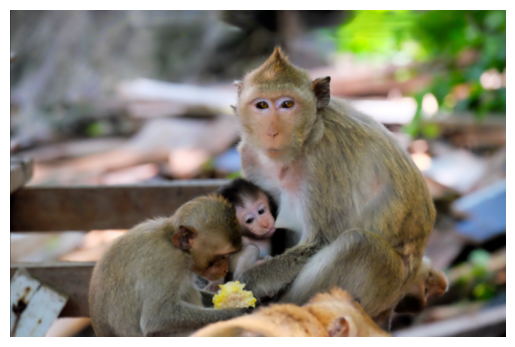

In [34]:
import matplotlib.pyplot as plt

img_path = os.path.join(folder_path, "03869.png")
img = Image.open(img_path).convert("RGB")
plt.imshow(img)
plt.axis("off")
plt.show()